# Center-Inclusive Marker Ablation Radius

Train a GIN model and quantify marker perturbation effects for every graph-hop distance inside the model receptive field, including the center node (`hop = 0`). Results are summarized for the whole validation set and for dcrypt-defined regions. A separate center marker-positive stratification analysis compares unperturbed prediction quality for marker-positive versus marker-negative center cells.

In [1]:
import copy
import json
import pickle
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import numpy as np
import pandas as pd
import torch
from torch_geometric.loader import DataLoader

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("torch        =", torch.__version__)
print("cuda         =", torch.cuda.is_available())

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data
torch        = 2.8.0+cu128
cuda         = True


**Settings**

The first region covers the whole organoid. The remaining regions are defined from the minimum node-level `dcrypt` value. Ablation modes can be adjusted, but both `single` and `all` are included by default.

In [2]:
# Data and target settings
DATASET_NAME = "fixed_new"
TARGET_INDICES = [0]
TARGET_INDEX_FOR_PLOTS = 0
USE_GLOBAL_FEATURES = True
FILTER_BLACKLISTED_ORGANOIDS = True

# Optional target residualization against a train-only global-feature baseline
SUBTRACT_CONSTANT_GLOBAL_BASELINE = False

# Filtering and preprocessing settings
MISSING_COMPLEXITY_GROUP = {
    "dataset": "20251201",
    "timepoint": "day4p5",
    "fill_value": 2.1,
}
SPHERICITY_MAX = 0.92
SPHERICAL_MARKER_DIVERSITY_MIN = 0.5
COMPLEXITY_MIN = 2.0
INTERPOLATE_TARGET_OUTLIERS = True
OUTLIER_CLIP_QUANTILES = (0.005, 0.995)

# Split and region settings
VAL_FRAC = 0.30
SPLIT_SEED = None
DCRYPT_FIELD = "d_crypts_graph"
DCRYPT_REGION_ORDER = [
    "whole_organoid",
    "dcrypt_lt_0p8",
    "dcrypt_0p8_to_1p2",
    "dcrypt_gt_1p2",
    "no_crypt",
]
DCRYPT_REGION_LABELS = {
    "whole_organoid": "whole organoid",
    "dcrypt_lt_0p8": "dcrypt < 0.75",
    "dcrypt_0p8_to_1p2": "0.75 <= dcrypt <= 1.2",
    "dcrypt_gt_1p2": "dcrypt > 1.2",
    "no_crypt": "no crypt",
}

# Model settings
MODEL_CLASS = "GINCurvature"
NUM_LAYERS = 4
HIDDEN_DIM = 4 * 64
DROPOUT = 0.1
NORM = "batch"
RESIDUAL = True

# Training settings
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4
PREDICT_BATCH_SIZE = 128
EDGE_LOSS_WEIGHT = 0.20
EDGE_LOSS_PARAMS = {
    "weighted": False,
    "alpha": 2.0,
    "normalize_by": "graph_std",
    "clip_weight": 4.0,
}

# Center-inclusive ablation settings
ABLATION_MODES = ["single"]
ABLATION_NORMALIZE_BY_BY_MODE = {
    "single": "perturbed_cells",
}
MAX_SUBGRAPHS_PER_GROUP = 2500
MIN_CENTER_MARKER_OCCURRENCES = 75
MIN_GROUP_NODES = 30
PERTURBATION_BATCH_SIZE = 128
RANDOM_SEED = 1

# Experiment output settings
EXPERIMENT_GROUP = "center_inclusive_marker_ablation_radius"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_NAME = f"run_{RUN_TIMESTAMP}"
SAVE_DIR = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME
FIGURES_DIR = SAVE_DIR / "figures"

In [3]:
def save_mpl_figure(fig, name, *, dpi=300):
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    path = FIGURES_DIR / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight", dpi=dpi)
    print(f"Saved figure -> {path}")
    return path


def select_target_column(values, target_index=0):
    arr = np.asarray(values)
    if arr.ndim == 1:
        return arr.reshape(-1)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return arr[:, 0]
    if arr.ndim == 2:
        return arr[:, int(target_index)]
    raise ValueError(f"Expected 1-D or 2-D target array, got shape {arr.shape}")


def marker_index(name, marker_names_in):
    marker_names_in = list(marker_names_in)
    if name in marker_names_in:
        return marker_names_in.index(name)
    lower = {str(m).lower(): i for i, m in enumerate(marker_names_in)}
    key = str(name).lower()
    if key not in lower:
        raise ValueError(f"Marker {name!r} not found in marker_names: {marker_names_in}")
    return lower[key]


def display_table(df, *, columns=None, head=None):
    out = df.copy()
    out = out.drop(columns=["group"], errors="ignore")
    if columns is not None:
        out = out[[col for col in columns if col in out.columns]]
    if head is not None:
        out = out.head(int(head))
    display(out)


def sem(values):
    values = np.asarray(values, dtype=float).reshape(-1)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return float(np.std(values, ddof=1) / np.sqrt(values.size)) if values.size > 1 else 0.0


def _select_center_target_value(y_center, target_index=0):
    arr = y_center.detach().cpu().numpy() if torch.is_tensor(y_center) else np.asarray(y_center)
    arr = np.asarray(arr)
    if arr.ndim == 0:
        return float(arr)
    if arr.ndim == 1:
        return float(arr[0] if arr.shape[0] == 1 else arr[int(target_index)])
    raise ValueError(f"Expected scalar or 1-D center target, got shape {arr.shape}.")

**Data Loading**

In [4]:
from src.data.io import load_graph_dataset_from_dir, select_graph_targets
from src.data.metadata import (
    attach_metadata_to_graphs,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = DATA_ROOT / DATASET_NAME
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")
if graphs:
    print("Raw y shape:", tuple(graphs[0].y.shape))

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(graphs, meta, exclude_keys=None)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

graphs = select_graph_targets(graphs, target_indices=TARGET_INDICES, inplace=False)
if graphs:
    print("Selected y shape:", tuple(graphs[0].y.shape))

marker_names = load_marker_names_from_dir(str(data_dir))
if marker_names is None:
    n_markers = int(graphs[0].x.size(1)) if graphs else 0
    marker_names = [f"marker_{i}" for i in range(n_markers)]
print(f"Loaded {len(marker_names)} markers:", marker_names)

print_graph_and_metadata_fields(graphs)

Loaded 1423 graphs; skipped 0.
Loaded 1423 organoids.
Raw y shape: (165, 2)
Attached metadata to 1423/1423 graphs.
Selected y shape: (165,)
Loaded 7 markers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin']
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - d_crypts_graph
  - d_crypts_mesh_shape
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mean_gaussian_curvature
  - mean_mean_curvature
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - segmentation_path
  - timepoint
  - total_curvature_discrete
  - total_mean_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner
  - y_columns


In [5]:
# Optional day3p5 timepoint filter
from src.data.filters import filter_graphs_by_metadata

DAY3P5_TIMEPOINT = "day3p5"

# Default: remove day3p5 graphs if present.
graphs = filter_graphs_by_metadata(
    graphs,
    key="timepoint",
    drop_values={DAY3P5_TIMEPOINT},
    missing="keep",
    inplace=False,
    print_summary=True,
)

# Alternative: keep only day3p5 graphs and filter out all other timepoints.
# Uncomment this block and comment out the default block above if needed.
# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     keep_values={DAY3P5_TIMEPOINT},
#     missing="drop",
#     inplace=False,
#     print_summary=True,
# )


filter_graphs_by_metadata(key='timepoint'): kept 1134 / 1423 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day3p5                0    289    0.000
20250929         day4                342    342    1.000
20250929         day4p5              104    104    1.000
20250929         day4p5-more         411    411    1.000
20251201         day4p5              277    277    1.000


**Filtering And Global Features**

In [6]:
from src.data.filters import (
    filter_graphs_by_blacklist,
    filter_graphs_by_marker_diversity,
    filter_graphs_by_numeric_metadata,
    filter_graphs_by_sphericity,
    load_graph_blacklist_from_dir,
)
from src.data.metadata import (
    add_log_metadata_features,
    fill_missing_metadata_for_group,
    promote_metadata_to_graph_tensors,
)
from src.data.preprocessing import interpolate_target_outliers_from_neighbors

if FILTER_BLACKLISTED_ORGANOIDS:
    blacklist = load_graph_blacklist_from_dir(data_dir)
    graphs = filter_graphs_by_blacklist(graphs, blacklist, print_summary=True)
else:
    blacklist = set()
    print("Blacklist filtering disabled.")

graphs = fill_missing_metadata_for_group(
    graphs,
    field="complexity",
    fill_value=MISSING_COMPLEXITY_GROUP["fill_value"],
    dataset=MISSING_COMPLEXITY_GROUP["dataset"],
    timepoint=MISSING_COMPLEXITY_GROUP["timepoint"],
)

graphs, g_spherical = filter_graphs_by_sphericity(
    graphs,
    max_sphericity=SPHERICITY_MAX,
    print_summary=True,
    return_rejected=True,
)
g_spherical = filter_graphs_by_marker_diversity(
    g_spherical,
    min_score=SPHERICAL_MARKER_DIVERSITY_MIN,
    print_summary=True,
)
graphs = filter_graphs_by_numeric_metadata(
    graphs,
    key="complexity",
    min_value=COMPLEXITY_MIN,
    allow_missing=False,
    inplace=False,
    print_summary=True,
)
graphs = graphs + g_spherical
print(f"After filtering and spherical rescue: {len(graphs)} organoids.")

if INTERPOLATE_TARGET_OUTLIERS:
    graphs, outlier_info = interpolate_target_outliers_from_neighbors(
        graphs,
        target_indices=None,
        clip_quantiles=OUTLIER_CLIP_QUANTILES,
    )
else:
    outlier_info = None

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

if USE_GLOBAL_FEATURES:
    graphs = add_log_metadata_features(graphs, inplace=False)
    graphs = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)
    print("Promoted metadata fields to graph tensor attributes.")
else:
    print("Global features disabled; no global_feat attribute was attached.")

filter_graphs_by_blacklist(n_keys=6): kept 1128 / 1134 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                341    342    0.997
20250929         day4p5              104    104    1.000
20250929         day4p5-more         409    411    0.995
20251201         day4p5              274    277    0.989
filter_graphs_by_sphericity(max_sphericity=0.92): kept 813 / 1128 graphs

dataset          timepoint          kept  total     frac
----------------------------------------------------------
20250929         day4                243    341    0.713
20250929         day4p5               89    104    0.856
20250929         day4p5-more         288    409    0.704
20251201         day4p5              193    274    0.704
filter_graphs_by_marker_diversity(min_score=0.5, top_k=None): kept 89 / 315 graphs

dataset          timepoint          kept  total     frac
----------------------------------

**Split And Target Transform**

In [7]:
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.splits import graph_metadata_key, train_val_split_graphs
from src.data.target_transforms import (
    AsinhStandardizeTransform,
    ChainedTargetTransform,
    GlobalBaselineResidualTransform,
    standardize_graph_global_features,
)

g_train, g_val, split_info = train_val_split_graphs(
    graphs,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
    key_fn=graph_metadata_key,
)
print(f"Split -> train: {len(g_train)} | val: {len(g_val)}")

train_meta_lookup = snapshot_graph_metadata(g_train)
val_meta_lookup = snapshot_graph_metadata(g_val)

g_train = strip_graph_metadata(g_train, inplace=False)
g_val = strip_graph_metadata(g_val, inplace=False)

center_global, scale_global = None, None
if USE_GLOBAL_FEATURES:
    center_global, scale_global = standardize_graph_global_features(
        g_train,
        g_val,
        attr_name="global_feat",
        robust=False,
    )

if SUBTRACT_CONSTANT_GLOBAL_BASELINE:
    if not USE_GLOBAL_FEATURES:
        raise ValueError("SUBTRACT_CONSTANT_GLOBAL_BASELINE requires USE_GLOBAL_FEATURES=True.")
    target_transform = ChainedTargetTransform([
        GlobalBaselineResidualTransform(num_workers=NUM_WORKERS),
        AsinhStandardizeTransform(robust=True),
    ])
    training_target_description = "target residual: true curvature - global-feature baseline"
else:
    target_transform = AsinhStandardizeTransform(robust=True)
    training_target_description = "raw target"

print("Training target:", training_target_description)

target_transform.fit(g_train)
target_transform.transform_graphs(g_train)
target_transform.transform_graphs(g_val)

global_dim = infer_global_dim(g_train)
print("global_dim =", global_dim)
print("target_transform =", target_transform.name)

Split -> train: 557 | val: 238
Training target: raw target
global_dim = 4
target_transform = asinh_standardize


**Train Model**

In [8]:
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

aux_losses = [
    WeightedLossTerm(
        name="edge",
        fn=edge_loss_term,
        weight=EDGE_LOSS_WEIGHT,
        params=EDGE_LOSS_PARAMS,
    ),
]

cfg = TrainConfig(
    lr=LR,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    num_workers=NUM_WORKERS,
    aux_losses=aux_losses,
)

device = cfg.device
print("device =", device)


def infer_target_dim_from_graphs(graphs_in):
    y = graphs_in[0].y
    return 1 if y.ndim == 1 else int(y.shape[1])


model = GINCurvature(
    n_markers=int(g_train[0].x.size(1)),
    global_dim=infer_global_dim(g_train),
    hidden_dim=HIDDEN_DIM,
    num_layers=int(NUM_LAYERS),
    dropout=DROPOUT,
    residual=RESIDUAL,
    norm=NORM,
    target_dim=infer_target_dim_from_graphs(g_train),
)
model, metrics, history = train(model, g_train, g_val, cfg)
training_log = {
    "model_class": MODEL_CLASS,
    "variant": "all_markers",
    "num_layers": int(NUM_LAYERS),
    "metrics": metrics,
    "history": history,
}
print("Finished training.")

device = cuda
epoch 001 | train loss 0.6580 mae 0.8221 | val loss 0.5048 mae 0.7589
epoch 002 | train loss 0.5436 mae 0.7600 | val loss 0.4669 mae 0.7337
epoch 003 | train loss 0.4949 mae 0.7370 | val loss 0.4407 mae 0.7146
epoch 004 | train loss 0.4548 mae 0.7145 | val loss 0.4335 mae 0.7208
epoch 005 | train loss 0.4392 mae 0.7067 | val loss 0.4000 mae 0.6897
epoch 006 | train loss 0.4145 mae 0.6933 | val loss 0.3939 mae 0.6922
epoch 007 | train loss 0.4003 mae 0.6836 | val loss 0.3932 mae 0.6917
epoch 008 | train loss 0.3904 mae 0.6797 | val loss 0.3659 mae 0.6700
epoch 009 | train loss 0.3864 mae 0.6777 | val loss 0.3487 mae 0.6611
epoch 010 | train loss 0.3712 mae 0.6676 | val loss 0.3383 mae 0.6517
epoch 011 | train loss 0.3652 mae 0.6654 | val loss 0.3384 mae 0.6531
epoch 012 | train loss 0.3584 mae 0.6600 | val loss 0.3607 mae 0.6739
epoch 013 | train loss 0.3596 mae 0.6615 | val loss 0.3363 mae 0.6527
epoch 014 | train loss 0.3468 mae 0.6557 | val loss 0.3503 mae 0.6651
epoch 

**Validation Predictions And Regions**

In [9]:
from src.data.metadata import get_graph_metadata
from src.inference.predict import predict_targets


def predict_model_arrays(graphs_in, model_in):
    y_true_i, y_pred_i, log_var_i, _ = predict_targets(
        graphs_in,
        model_in,
        device=device,
        batch_size=PREDICT_BATCH_SIZE,
        target_transform=target_transform,
        return_log_var=True,
    )
    y_true_i = select_target_column(y_true_i, TARGET_INDEX_FOR_PLOTS)
    y_pred_i = select_target_column(y_pred_i, TARGET_INDEX_FOR_PLOTS)
    log_var_i = select_target_column(log_var_i, TARGET_INDEX_FOR_PLOTS)
    pred_var_i = np.exp(log_var_i)
    sqerr_i = (y_pred_i - y_true_i) ** 2
    return {
        "y_true": y_true_i,
        "y_pred": y_pred_i,
        "log_var": log_var_i,
        "pred_var": pred_var_i,
        "sqerr": sqerr_i,
    }


pred_full = predict_model_arrays(g_val, model)
y_true = pred_full["y_true"]
y_pred = pred_full["y_pred"]
pred_var = pred_full["pred_var"]
sqerr = pred_full["sqerr"]

print("Validation nodes:", len(y_true))
print("MSE:", float(np.mean(sqerr)))
print("Mean predicted variance:", float(np.mean(pred_var)))


def _nanmin_or_nan(values, axis):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    filled = np.where(finite, arr, np.inf)
    out = np.min(filled, axis=axis)
    has_finite = np.any(finite, axis=axis)
    out = np.asarray(out, dtype=float)
    out[~has_finite] = np.nan
    return out


def _min_node_dcrypt_from_raw(raw, n_nodes):
    arr = np.asarray(raw, dtype=float)
    if arr.size == 0:
        return np.full(n_nodes, np.nan, dtype=float)
    if arr.ndim == 0:
        return np.full(n_nodes, float(arr), dtype=float)
    if arr.ndim == 1:
        if arr.shape[0] == n_nodes:
            return arr.astype(float)
        if arr.shape[0] == 1:
            return np.full(n_nodes, float(arr[0]), dtype=float)
        raise ValueError(f"Cannot align 1-D dcrypt with length {arr.shape[0]} to {n_nodes} nodes.")
    if n_nodes in arr.shape:
        node_axis = list(arr.shape).index(n_nodes)
        moved = np.moveaxis(arr, node_axis, 0).reshape(n_nodes, -1)
        return _nanmin_or_nan(moved, axis=1)
    if arr.ndim >= 2 and arr.shape[1] >= n_nodes:
        vals = _nanmin_or_nan(arr, axis=0)
    else:
        vals = _nanmin_or_nan(arr, axis=1)
    vals = np.asarray(vals, dtype=float).reshape(-1)
    if vals.shape[0] != n_nodes:
        raise ValueError(f"Transformed dcrypt has length {vals.shape[0]}, expected {n_nodes}.")
    return vals


def compute_min_dcrypt_by_graphs(graphs_in, *, meta_lookup=None, field=DCRYPT_FIELD):
    values_by_graph = []
    for g in graphs_in:
        n_nodes = int(g.y.shape[0])
        md = get_graph_metadata(g, meta_lookup=meta_lookup, strict=False, default={})
        raw = md.get(field, np.asarray([], dtype=float))
        values_by_graph.append(_min_node_dcrypt_from_raw(raw, n_nodes))
    return values_by_graph, np.concatenate(values_by_graph, axis=0)


def dcrypt_region_masks(dcrypt_values):
    dcrypt_values = np.asarray(dcrypt_values, dtype=float).reshape(-1)
    finite = np.isfinite(dcrypt_values)
    return {
        "dcrypt_lt_0p8": finite & (dcrypt_values < 0.75),
        "dcrypt_0p8_to_1p2": finite & (dcrypt_values >= 0.75) & (dcrypt_values <= 1.2),
        "dcrypt_gt_1p2": finite & (dcrypt_values > 1.2),
        "no_crypt": ~finite,
    }


min_dcrypt_by_graph, min_dcrypt_by_node = compute_min_dcrypt_by_graphs(
    g_val,
    meta_lookup=val_meta_lookup,
    field=DCRYPT_FIELD,
)
if len(min_dcrypt_by_node) != len(y_true):
    raise ValueError(f"dcrypt length {len(min_dcrypt_by_node)} does not match validation target length {len(y_true)}.")

analysis_masks = {"whole_organoid": np.ones(len(y_true), dtype=bool)}
analysis_masks.update(dcrypt_region_masks(min_dcrypt_by_node))
analysis_group_count_df = pd.DataFrame([
    {
        "group": group,
        "label": DCRYPT_REGION_LABELS[group],
        "n_nodes": int(analysis_masks[group].sum()),
    }
    for group in DCRYPT_REGION_ORDER
])
display_table(analysis_group_count_df)

Validation nodes: 115819
MSE: 0.001952998945837709
Mean predicted variance: 0.0011791330805086618


,label,n_nodes
0,whole organoid,115819
1,dcrypt < 0.75,21914
2,0.75 <= dcrypt <= 1.2,28180
3,dcrypt > 1.2,51473
4,no crypt,14252


**Center Marker-Positive Stratification**

This unperturbed analysis compares prediction quality on marker-positive versus marker-negative center cells in each region.

In [10]:
def center_marker_positive_matrix(graphs_in, marker_names_in):
    n_markers = len(marker_names_in)
    parts = []
    for g in graphs_in:
        x = g.x.detach().cpu().numpy() if hasattr(g.x, "detach") else np.asarray(g.x)
        parts.append(x[:, :n_markers] > 0.5)
    return np.concatenate(parts, axis=0)


center_marker_positive = center_marker_positive_matrix(g_val, marker_names)


def summarize_center_marker_stratification(group_masks):
    rows = []
    contrast_rows = []
    for group in DCRYPT_REGION_ORDER:
        group_mask = np.asarray(group_masks[group], dtype=bool)
        for mi, marker in enumerate(marker_names):
            metric_by_state = {}
            for state_label, state_mask in [
                ("positive", center_marker_positive[:, mi]),
                ("negative", ~center_marker_positive[:, mi]),
            ]:
                mask = group_mask & state_mask
                n = int(mask.sum())
                if n == 0:
                    row = {
                        "group": group,
                        "label": DCRYPT_REGION_LABELS[group],
                        "marker": marker,
                        "marker_index": mi,
                        "state": state_label,
                        "n_nodes": n,
                        "mse": np.nan,
                        "sem_mse": np.nan,
                        "mean_true": np.nan,
                        "mean_pred": np.nan,
                        "std_pred": np.nan,
                        "var_pred": np.nan,
                        "sem_pred": np.nan,
                        "mean_pred_var": np.nan,
                    }
                else:
                    pred_values = y_pred[mask]
                    pred_std = float(np.std(pred_values, ddof=1)) if n > 1 else 0.0
                    row = {
                        "group": group,
                        "label": DCRYPT_REGION_LABELS[group],
                        "marker": marker,
                        "marker_index": mi,
                        "state": state_label,
                        "n_nodes": n,
                        "mse": float(np.mean(sqerr[mask])),
                        "sem_mse": sem(sqerr[mask]),
                        "mean_true": float(np.mean(y_true[mask])),
                        "mean_pred": float(np.mean(pred_values)),
                        "std_pred": pred_std,
                        "var_pred": float(pred_std ** 2),
                        "sem_pred": float(pred_std / np.sqrt(n)) if n > 1 else 0.0,
                        "mean_pred_var": float(np.mean(pred_var[mask])),
                    }
                rows.append(row)
                metric_by_state[state_label] = row
            pos = metric_by_state["positive"]
            neg = metric_by_state["negative"]
            strat_delta_var = (
                pos["var_pred"] + neg["var_pred"]
                if np.isfinite(pos["var_pred"]) and np.isfinite(neg["var_pred"])
                else np.nan
            )
            strat_delta_sem = (
                np.sqrt(pos["var_pred"] / pos["n_nodes"] + neg["var_pred"] / neg["n_nodes"])
                if pos["n_nodes"] > 0 and neg["n_nodes"] > 0 and np.isfinite(strat_delta_var)
                else np.nan
            )
            contrast_rows.append({
                "group": group,
                "label": DCRYPT_REGION_LABELS[group],
                "marker": marker,
                "marker_index": mi,
                "n_positive": pos["n_nodes"],
                "n_negative": neg["n_nodes"],
                "delta_mse_pos_minus_neg": pos["mse"] - neg["mse"],
                "delta_true_pos_minus_neg": pos["mean_true"] - neg["mean_true"],
                "delta_pred_pos_minus_neg": pos["mean_pred"] - neg["mean_pred"],
                "var_delta_pred_pos_minus_neg": strat_delta_var,
                "sem_delta_pred_pos_minus_neg": strat_delta_sem,
                "delta_pred_var_pos_minus_neg": pos["mean_pred_var"] - neg["mean_pred_var"],
            })
    return pd.DataFrame(rows), pd.DataFrame(contrast_rows)


center_marker_stratification_df, center_marker_stratification_contrast_df = summarize_center_marker_stratification(analysis_masks)
display_table(center_marker_stratification_df, head=12)
display_table(center_marker_stratification_contrast_df, head=12)

,label,marker,marker_index,state,n_nodes,mse,sem_mse,mean_true,mean_pred,std_pred,var_pred,sem_pred,mean_pred_var
0,whole organoid,Agr2,0,positive,6078,0.002141,0.000063,0.050120,0.045667,0.032038,0.001026,0.000411,0.001300
1,whole organoid,Agr2,0,negative,109741,0.001943,0.000015,0.031719,0.032752,0.030259,0.000916,0.000091,0.001172
2,whole organoid,AldoB,1,positive,43706,0.001565,0.000022,0.025453,0.028228,0.028879,0.000834,0.000138,0.000972
3,whole organoid,AldoB,1,negative,72113,0.002188,0.000020,0.037067,0.036582,0.031006,0.000961,0.000115,0.001305
4,whole organoid,Chroma,2,positive,536,0.003035,0.000275,0.078500,0.075636,0.036387,0.001324,0.001572,0.001955
5,whole organoid,Chroma,2,negative,115283,0.001948,0.000015,0.032471,0.033233,0.030324,0.000920,0.000089,0.001176
6,whole organoid,KI67,3,positive,38021,0.002090,0.000026,0.038575,0.037855,0.028010,0.000785,0.000144,0.001181
7,whole organoid,KI67,3,negative,77798,0.001886,0.000018,0.029805,0.031267,0.031407,0.000986,0.000113,0.001178
8,whole organoid,LGR5,4,positive,18087,0.002202,0.000039,0.057101,0.052707,0.022115,0.000489,0.000164,0.001116
9,whole organoid,LGR5,4,negative,97732,0.001907,0.000016,0.028166,0.029862,0.030492,0.000930,0.000098,0.001191


,label,marker,marker_index,n_positive,n_negative,delta_mse_pos_minus_neg,delta_true_pos_minus_neg,delta_pred_pos_minus_neg,var_delta_pred_pos_minus_neg,sem_delta_pred_pos_minus_neg,delta_pred_var_pos_minus_neg
0,whole organoid,Agr2,0,6078,109741,0.000198,0.018402,0.012915,0.001942,0.000421,0.000127
1,whole organoid,AldoB,1,43706,72113,-0.000623,-0.011613,-0.008354,0.001795,0.000180,-0.000333
2,whole organoid,Chroma,2,536,115283,0.001087,0.046029,0.042403,0.002244,0.001574,0.000780
3,whole organoid,KI67,3,38021,77798,0.000203,0.008769,0.006588,0.001771,0.000183,0.000002
4,whole organoid,LGR5,4,18087,97732,0.000295,0.028935,0.022845,0.001419,0.000191,-0.000075
5,whole organoid,Lysozyme,5,1480,114339,0.000412,0.042017,0.035400,0.001538,0.000654,0.000539
6,whole organoid,Serotonin,6,436,115383,0.001512,0.068498,0.053978,0.002077,0.001633,0.001139
7,dcrypt < 0.75,Agr2,0,1784,20130,0.000410,0.015601,0.013419,0.001666,0.000731,0.000324
8,dcrypt < 0.75,AldoB,1,5396,16518,-0.001913,-0.025261,-0.011841,0.001205,0.000324,-0.001038
9,dcrypt < 0.75,Chroma,2,288,21626,0.000768,0.026855,0.038051,0.002036,0.002097,0.001089


**Stratification Heatmaps**

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/center_inclusive_marker_ablation_radius/run_20260605_160706/figures/center_marker_positive_minus_negative_mse.pdf


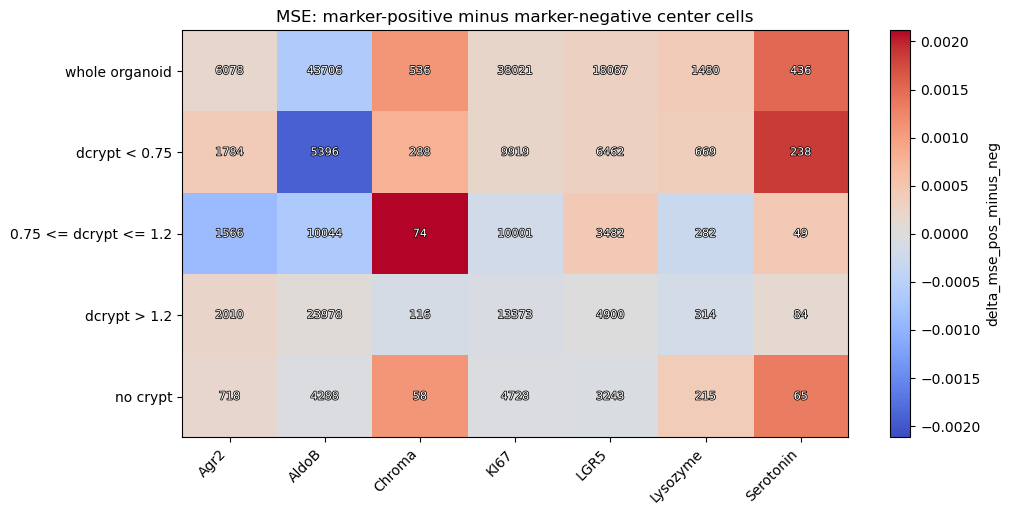

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/center_inclusive_marker_ablation_radius/run_20260605_160706/figures/center_marker_positive_minus_negative_true_curvature.pdf


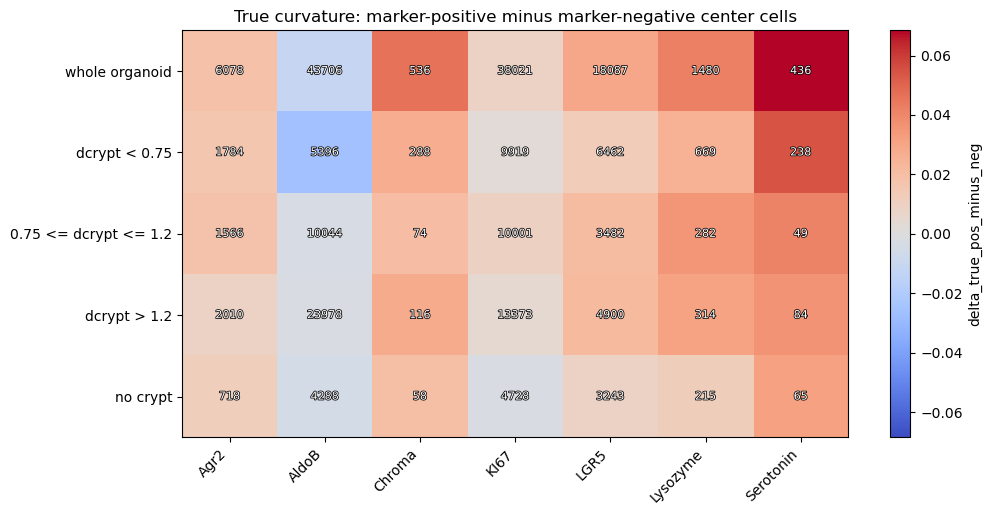

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/center_inclusive_marker_ablation_radius/run_20260605_160706/figures/center_marker_positive_minus_negative_predicted_variance.pdf


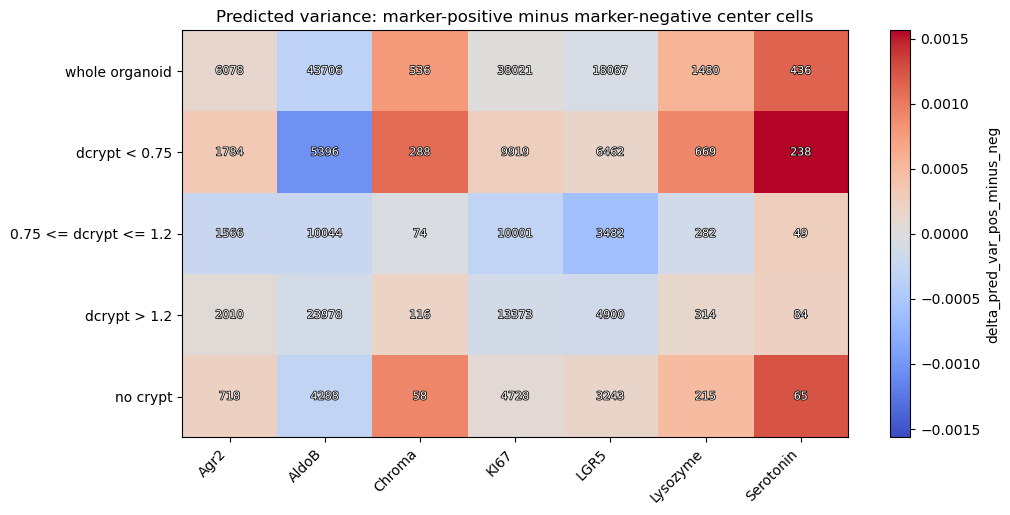

In [11]:
def annotate_heatmap_cells(ax, annotation_table, *, fontsize=8):
    values = annotation_table.to_numpy()
    for yi in range(values.shape[0]):
        for xi in range(values.shape[1]):
            value = values[yi, xi]
            if pd.isna(value):
                continue
            text = ax.text(
                xi,
                yi,
                f"{int(value)}",
                ha="center",
                va="center",
                fontsize=fontsize,
                color="white",
            )
            text.set_path_effects([path_effects.withStroke(linewidth=1.1, foreground="black")])


def plot_region_marker_heatmap(
    df,
    value_col,
    title,
    filename,
    *,
    group_order,
    cmap="coolwarm",
    center_zero=True,
    annotation_col="n_positive",
):
    sub = df[df["group"].isin(group_order)].copy()
    table = sub.pivot(index="label", columns="marker", values=value_col)
    row_labels = [DCRYPT_REGION_LABELS[g] for g in group_order if g in set(sub["group"])]
    table = table.reindex(row_labels)
    table = table.reindex(columns=[m for m in marker_names if m in table.columns])

    annotation_table = None
    if annotation_col is not None and annotation_col in sub.columns:
        annotation_table = sub.pivot(index="label", columns="marker", values=annotation_col)
        annotation_table = annotation_table.reindex(row_labels)
        annotation_table = annotation_table.reindex(columns=table.columns)

    values = table.to_numpy(dtype=float)
    if center_zero and np.any(np.isfinite(values)):
        vmax = np.nanmax(np.abs(values))
        vmin = -vmax
    else:
        vmin = vmax = None

    fig, ax = plt.subplots(figsize=(1.05 * len(table.columns) + 3, 0.55 * len(table.index) + 2.5))
    im = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(table.columns)))
    ax.set_xticklabels(table.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(table.index)))
    ax.set_yticklabels(table.index)
    if annotation_table is not None:
        annotate_heatmap_cells(ax, annotation_table)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value_col)
    fig.tight_layout()
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, ax


for value_col, title, filename, cmap in [
    ("delta_mse_pos_minus_neg", "MSE: marker-positive minus marker-negative center cells", "center_marker_positive_minus_negative_mse", "coolwarm"),
    ("delta_true_pos_minus_neg", "True curvature: marker-positive minus marker-negative center cells", "center_marker_positive_minus_negative_true_curvature", "coolwarm"),
    ("delta_pred_var_pos_minus_neg", "Predicted variance: marker-positive minus marker-negative center cells", "center_marker_positive_minus_negative_predicted_variance", "coolwarm"),
]:
    plot_region_marker_heatmap(
        center_marker_stratification_contrast_df,
        value_col,
        title,
        filename,
        group_order=DCRYPT_REGION_ORDER,
        cmap=cmap,
        center_zero=True,
        annotation_col="n_positive",
    )

**Build Subgraphs**

In [12]:
from src.data.subgraphs import build_ego_subgraphs_for_center_specs


def _as_numpy_feature_matrix(g):
    if hasattr(g.x, "detach"):
        return g.x.detach().cpu().numpy()
    return np.asarray(g.x)


def _candidate_specs_and_center_markers(graphs_in, flat_mask, marker_names_in):
    flat_mask = np.asarray(flat_mask, dtype=bool).reshape(-1)
    specs = []
    marker_parts = []
    offset = 0
    n_markers = len(marker_names_in)
    for gi, g in enumerate(graphs_in):
        n = int(g.x.shape[0])
        local = np.where(flat_mask[offset:offset + n])[0]
        if local.size > 0:
            x = _as_numpy_feature_matrix(g)
            specs.extend((gi, int(c)) for c in local)
            marker_parts.append(x[local, :n_markers] > 0.5)
        offset += n
    if marker_parts:
        center_marker_positive = np.concatenate(marker_parts, axis=0)
    else:
        center_marker_positive = np.zeros((0, n_markers), dtype=bool)
    return specs, center_marker_positive


def center_specs_from_flat_mask(
    graphs_in,
    flat_mask,
    marker_names_in,
    *,
    max_centers=None,
    min_marker_occurrences=0,
    seed=0,
):
    specs, center_marker_positive = _candidate_specs_and_center_markers(
        graphs_in,
        flat_mask,
        marker_names_in,
    )
    if max_centers is None or len(specs) <= int(max_centers):
        return specs

    rng = np.random.default_rng(seed)
    max_centers = int(max_centers)
    min_marker_occurrences = int(min_marker_occurrences or 0)
    selected = set()

    if min_marker_occurrences > 0:
        for mi in range(center_marker_positive.shape[1]):
            candidates = np.where(center_marker_positive[:, mi])[0]
            if candidates.size == 0:
                continue
            take_n = min(min_marker_occurrences, int(candidates.size))
            chosen = rng.choice(candidates, size=take_n, replace=False)
            selected.update(int(i) for i in chosen)

    remaining_budget = max_centers - len(selected)
    if remaining_budget > 0:
        remaining = np.asarray([i for i in range(len(specs)) if i not in selected], dtype=int)
        if remaining.size > 0:
            chosen = rng.choice(
                remaining,
                size=min(remaining_budget, int(remaining.size)),
                replace=False,
            )
            selected.update(int(i) for i in chosen)
    elif len(selected) > max_centers:
        print(
            f"Marker coverage selected {len(selected)} centers, exceeding "
            f"MAX_SUBGRAPHS_PER_GROUP={max_centers}. Keeping them to preserve center-marker coverage."
        )

    return [specs[i] for i in sorted(selected)]


def sampled_center_marker_counts(graphs_in, specs, marker_names_in):
    counts = {marker: 0 for marker in marker_names_in}
    n_markers = len(marker_names_in)
    for gi, center_idx in specs:
        x = _as_numpy_feature_matrix(graphs_in[gi])
        values = x[int(center_idx), :n_markers] > 0.5
        for marker, is_positive in zip(marker_names_in, values):
            counts[marker] += int(is_positive)
    return counts


def build_group_subgraphs(group_masks):
    out = {}
    info = []
    for group in DCRYPT_REGION_ORDER:
        mask = np.asarray(group_masks[group], dtype=bool)
        specs = center_specs_from_flat_mask(
            g_val,
            mask,
            marker_names,
            max_centers=MAX_SUBGRAPHS_PER_GROUP,
            min_marker_occurrences=MIN_CENTER_MARKER_OCCURRENCES,
            seed=RANDOM_SEED,
        )
        sampled_marker_counts = sampled_center_marker_counts(g_val, specs, marker_names)
        if len(specs) == 0:
            out[group] = []
        else:
            out[group] = build_ego_subgraphs_for_center_specs(
                g_val,
                specs,
                num_hops=NUM_LAYERS,
                copy_graph_level_attrs=True,
            )
        info_row = {
            "group": group,
            "label": DCRYPT_REGION_LABELS[group],
            "n_nodes": int(mask.sum()),
            "n_subgraphs": len(out[group]),
            "min_center_marker_occurrences": MIN_CENTER_MARKER_OCCURRENCES,
        }
        info_row.update({
            f"n_center_{marker}": int(sampled_marker_counts[marker])
            for marker in marker_names
        })
        info.append(info_row)
    return out, pd.DataFrame(info)


group_subgraphs, group_subgraph_info = build_group_subgraphs(analysis_masks)
display_table(group_subgraph_info)


,label,n_nodes,n_subgraphs,min_center_marker_occurrences,n_center_Agr2,n_center_AldoB,n_center_Chroma,n_center_KI67,n_center_LGR5,n_center_Lysozyme,n_center_Serotonin
0,whole organoid,115819,2500,75,268,851,101,855,400,117,90
1,dcrypt < 0.75,21914,2500,75,311,603,120,1088,688,147,99
2,0.75 <= dcrypt <= 1.2,28180,2500,75,267,859,74,945,368,101,49
3,dcrypt > 1.2,51473,2500,75,228,1022,85,777,298,95,78
4,no crypt,14252,2500,75,215,716,58,845,576,112,65


**Center-Inclusive Ablation**

The local helper below differs from `src.analysis.perturbation.compute_perturbation_influence_maps()` by including `hop = 0`. It only returns total effects by perturbed marker and distance, not center-marker-resolved maps.

In [13]:
from src.analysis.perturbation import predict_subgraph_center_distribution
from src.graph.neighborhood import compute_hop_rings


def _subgraph_center_targets(subgraphs, target_index=0):
    y_center = []
    for g in subgraphs:
        c = int(g.center_idx)
        y_center.append(_select_center_target_value(g.y[c], target_index=target_index))
    return np.asarray(y_center, dtype=np.float64)


def _build_center_inclusive_marker_perturbations(subgraphs, n_markers, k_hops, hops, mode):
    if mode not in {"single", "all"}:
        raise ValueError("mode must be 'single' or 'all'.")
    perturbed = []
    meta = []
    for si, g in enumerate(subgraphs):
        c = int(g.center_idx)
        rings = compute_hop_rings(g.edge_index, c, int(k_hops))
        for hi, hop in enumerate(hops):
            nodes = rings[int(hop)]
            if len(nodes) == 0:
                continue
            for mi in range(n_markers):
                x_ring = g.x[nodes, mi]
                pos_mask = x_ring > 0.5
                n_pos = int(pos_mask.sum().item())
                if n_pos == 0:
                    continue
                gp = copy.deepcopy(g)
                x = gp.x.clone()
                ring_nodes_t = torch.as_tensor(nodes, device=x.device, dtype=torch.long)
                pos_idx = torch.nonzero(pos_mask, as_tuple=False).view(-1)
                if mode == "all":
                    x[ring_nodes_t[pos_idx], mi] = 0
                    n_pert = n_pos
                else:
                    node_to_zero = int(ring_nodes_t[int(pos_idx[0].item())].item())
                    x[node_to_zero, mi] = 0
                    n_pert = 1
                gp.x = x
                perturbed.append(gp)
                meta.append({
                    "subgraph_index": si,
                    "hop_index": hi,
                    "hop": int(hop),
                    "marker_index": mi,
                    "n_perturbed": int(n_pert),
                })
    return perturbed, meta


def _normalize_effect(total, total_abs, counts, cases, normalize_by):
    if normalize_by not in {"cases", "perturbed_cells"}:
        raise ValueError("normalize_by must be 'cases' or 'perturbed_cells'.")
    denom = cases if normalize_by == "cases" else counts
    mask = denom > 0
    total = total.copy()
    total_abs = total_abs.copy()
    total[mask] /= denom[mask]
    total_abs[mask] /= denom[mask]
    total[~mask] = np.nan
    total_abs[~mask] = np.nan
    return total, total_abs


def compute_center_inclusive_marker_ablation(subgraphs, model, marker_names, *, k_hops, mode, normalize_by, max_subgraphs=None):
    subs = list(subgraphs)
    if max_subgraphs is not None and len(subs) > int(max_subgraphs):
        rng = np.random.default_rng(RANDOM_SEED)
        idx = rng.choice(len(subs), size=int(max_subgraphs), replace=False)
        subs = [subs[int(i)] for i in idx]

    n_markers = len(marker_names)
    hops = list(range(0, int(k_hops) + 1))
    n_hops = len(hops)

    y_center = _subgraph_center_targets(subs, target_index=TARGET_INDEX_FOR_PLOTS)
    base_mu, base_lv = predict_subgraph_center_distribution(
        subs,
        model,
        device=device,
        batch_size=PERTURBATION_BATCH_SIZE,
        target_index=TARGET_INDEX_FOR_PLOTS,
    )
    _, base_mu, base_lv = target_transform.inverse_distribution(
        y_center,
        base_mu,
        log_var=base_lv,
        graphs=subs,
        center_only=True,
        target_index=TARGET_INDEX_FOR_PLOTS,
    )
    y_center = np.asarray(y_center, dtype=np.float64)
    base_mu = np.asarray(base_mu, dtype=np.float64)
    base_lv = np.asarray(base_lv, dtype=np.float64)
    base_sqerr = np.square(base_mu - y_center)

    perturbed, meta = _build_center_inclusive_marker_perturbations(
        subs,
        n_markers,
        k_hops,
        hops,
        mode,
    )
    if len(perturbed):
        pert_mu, pert_lv = predict_subgraph_center_distribution(
            perturbed,
            model,
            device=device,
            batch_size=PERTURBATION_BATCH_SIZE,
            target_index=TARGET_INDEX_FOR_PLOTS,
        )
        _, pert_mu, pert_lv = target_transform.inverse_distribution(
            None,
            pert_mu,
            log_var=pert_lv,
            graphs=perturbed,
            center_only=True,
            target_index=TARGET_INDEX_FOR_PLOTS,
        )
        pert_mu = np.asarray(pert_mu, dtype=np.float64)
        pert_lv = np.asarray(pert_lv, dtype=np.float64)
    else:
        pert_mu = np.zeros((0,), dtype=np.float64)
        pert_lv = np.zeros((0,), dtype=np.float64)

    total_mu = np.zeros((n_hops, n_markers), dtype=np.float64)
    total_abs_mu = np.zeros((n_hops, n_markers), dtype=np.float64)
    total_mse = np.zeros((n_hops, n_markers), dtype=np.float64)
    total_abs_mse = np.zeros((n_hops, n_markers), dtype=np.float64)
    total_lv = np.zeros((n_hops, n_markers), dtype=np.float64)
    counts = np.zeros((n_hops, n_markers), dtype=np.int64)
    cases = np.zeros((n_hops, n_markers), dtype=np.int64)
    case_rows = []

    for j, item in enumerate(meta):
        si = item["subgraph_index"]
        hi = item["hop_index"]
        mi = item["marker_index"]
        n_pert = item["n_perturbed"]
        delta_mu = float(pert_mu[j] - base_mu[si])
        delta_lv = float(pert_lv[j] - base_lv[si])
        delta_mse = float((pert_mu[j] - y_center[si]) ** 2 - base_sqerr[si])
        total_mu[hi, mi] += delta_mu
        total_abs_mu[hi, mi] += abs(delta_mu)
        total_mse[hi, mi] += delta_mse
        total_abs_mse[hi, mi] += abs(delta_mse)
        total_lv[hi, mi] += delta_lv
        counts[hi, mi] += n_pert
        cases[hi, mi] += 1
        case_rows.append({
            "subgraph_index": int(si),
            "hop": int(item["hop"]),
            "hop_index": int(hi),
            "marker": marker_names[mi],
            "marker_index": int(mi),
            "mode": mode,
            "normalize_by": normalize_by,
            "delta_mu": delta_mu,
            "delta_mse": delta_mse,
            "delta_log_var": delta_lv,
            "n_perturbed": int(n_pert),
            "base_sqerr": float(base_sqerr[si]),
        })

    delta_mu, delta_mu_abs = _normalize_effect(total_mu, total_abs_mu, counts, cases, normalize_by)
    delta_mse, delta_mse_abs = _normalize_effect(total_mse, total_abs_mse, counts, cases, normalize_by)
    delta_lv, _ = _normalize_effect(total_lv, np.abs(total_lv), counts, cases, normalize_by)

    rows = []
    for hi, hop in enumerate(hops):
        for mi, marker in enumerate(marker_names):
            rows.append({
                "hop": int(hop),
                "marker": marker,
                "marker_index": mi,
                "mode": mode,
                "normalize_by": normalize_by,
                "delta_mu": delta_mu[hi, mi],
                "delta_mu_abs": delta_mu_abs[hi, mi],
                "delta_mse": delta_mse[hi, mi],
                "delta_mse_abs": delta_mse_abs[hi, mi],
                "delta_log_var": delta_lv[hi, mi],
                "perturbed_cells": int(counts[hi, mi]),
                "cases": int(cases[hi, mi]),
                "n_subgraphs": len(subs),
            })
    return pd.DataFrame(rows), pd.DataFrame(case_rows)


ablation_frames = []
ablation_case_frames = []
for group in DCRYPT_REGION_ORDER:
    subs = group_subgraphs[group]
    if len(subs) < MIN_GROUP_NODES:
        print(f"Skipping {group}: only {len(subs)} subgraphs")
        continue
    for mode in ABLATION_MODES:
        normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, "perturbed_cells")
        print(f"Ablation | group={group} | mode={mode} | normalize_by={normalize_by} | subgraphs={len(subs)}")
        df_group, df_cases = compute_center_inclusive_marker_ablation(
            subs,
            model,
            marker_names,
            k_hops=NUM_LAYERS,
            mode=mode,
            normalize_by=normalize_by,
            max_subgraphs=None,
        )
        df_group["group"] = group
        df_group["label"] = DCRYPT_REGION_LABELS[group]
        df_cases["group"] = group
        df_cases["label"] = DCRYPT_REGION_LABELS[group]
        ablation_frames.append(df_group)
        ablation_case_frames.append(df_cases)

center_inclusive_ablation_df = pd.concat(ablation_frames, ignore_index=True)
center_inclusive_ablation_case_df = pd.concat(ablation_case_frames, ignore_index=True)
display_table(center_inclusive_ablation_df, head=12)
display_table(center_inclusive_ablation_case_df, head=12)

Ablation | group=whole_organoid | mode=single | normalize_by=perturbed_cells | subgraphs=2500
Ablation | group=dcrypt_lt_0p8 | mode=single | normalize_by=perturbed_cells | subgraphs=2500
Ablation | group=dcrypt_0p8_to_1p2 | mode=single | normalize_by=perturbed_cells | subgraphs=2500
Ablation | group=dcrypt_gt_1p2 | mode=single | normalize_by=perturbed_cells | subgraphs=2500
Ablation | group=no_crypt | mode=single | normalize_by=perturbed_cells | subgraphs=2500


,hop,marker,marker_index,mode,normalize_by,delta_mu,delta_mu_abs,delta_mse,delta_mse_abs,delta_log_var,perturbed_cells,cases,n_subgraphs,label
0,0,Agr2,0,single,perturbed_cells,-0.001989,0.006095,0.001094,0.012829,-0.032581,268,268,2500,whole organoid
1,0,AldoB,1,single,perturbed_cells,0.001104,0.004406,0.002145,0.007086,0.096018,851,851,2500,whole organoid
2,0,Chroma,2,single,perturbed_cells,-0.006878,0.012032,0.006516,0.028644,-0.105136,101,101,2500,whole organoid
3,0,KI67,3,single,perturbed_cells,-0.001495,0.003685,-0.001328,0.007012,0.025729,855,855,2500,whole organoid
4,0,LGR5,4,single,perturbed_cells,-0.001029,0.003072,-0.000865,0.005328,0.015504,400,400,2500,whole organoid
5,0,Lysozyme,5,single,perturbed_cells,-0.007855,0.009273,0.009205,0.019743,-0.141657,117,117,2500,whole organoid
6,0,Serotonin,6,single,perturbed_cells,-0.013287,0.015497,0.035210,0.047036,-0.226237,90,90,2500,whole organoid
7,1,Agr2,0,single,perturbed_cells,-0.001336,0.004949,0.002308,0.010514,-0.022651,622,622,2500,whole organoid
8,1,AldoB,1,single,perturbed_cells,0.001642,0.003519,0.001472,0.006420,0.058792,1114,1114,2500,whole organoid
9,1,Chroma,2,single,perturbed_cells,-0.004448,0.008624,0.008062,0.020854,-0.066475,131,131,2500,whole organoid


,subgraph_index,hop,hop_index,marker,marker_index,mode,normalize_by,delta_mu,delta_mse,delta_log_var,n_perturbed,base_sqerr,label
0,0,3,3,AldoB,1,single,perturbed_cells,-0.000592,0.001530,-0.002931,1,1.670980,whole organoid
1,0,4,4,AldoB,1,single,perturbed_cells,0.000148,-0.000382,0.001357,1,1.670980,whole organoid
2,1,2,2,AldoB,1,single,perturbed_cells,-0.001854,0.005146,0.034201,1,1.923090,whole organoid
3,1,3,3,AldoB,1,single,perturbed_cells,0.000917,-0.002543,0.030978,1,1.923090,whole organoid
4,1,4,4,AldoB,1,single,perturbed_cells,0.000225,-0.000623,0.003039,1,1.923090,whole organoid
5,2,4,4,KI67,3,single,perturbed_cells,0.001845,-0.003083,0.018723,1,0.699814,whole organoid
6,3,1,1,AldoB,1,single,perturbed_cells,-0.003401,-0.000520,0.112830,1,0.006103,whole organoid
7,3,2,2,AldoB,1,single,perturbed_cells,0.001038,0.000163,-0.051791,1,0.006103,whole organoid
8,3,3,3,AldoB,1,single,perturbed_cells,-0.005357,-0.000808,0.146805,1,0.006103,whole organoid
9,3,3,3,LGR5,4,single,perturbed_cells,0.014687,0.002510,-0.382029,1,0.006103,whole organoid


**Ablation Heatmaps**

Heatmaps show total effects by perturbed marker and graph-hop distance, including the center node at `hop = 0`. Positive `delta_mse` means marker removal worsened accuracy.

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/center_inclusive_marker_ablation_radius/run_20260605_160706/figures/center_inclusive_ablation_delta_mu_hop_marker_single.pdf


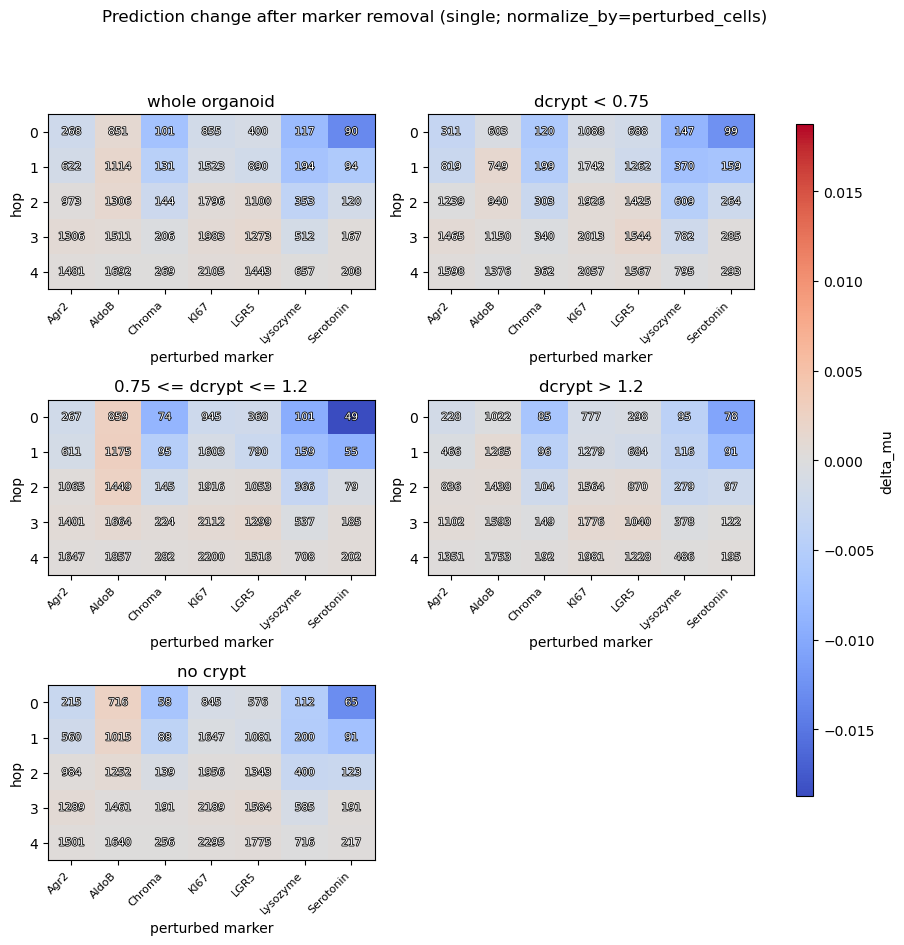

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/center_inclusive_marker_ablation_radius/run_20260605_160706/figures/center_inclusive_ablation_delta_mse_hop_marker_single.pdf


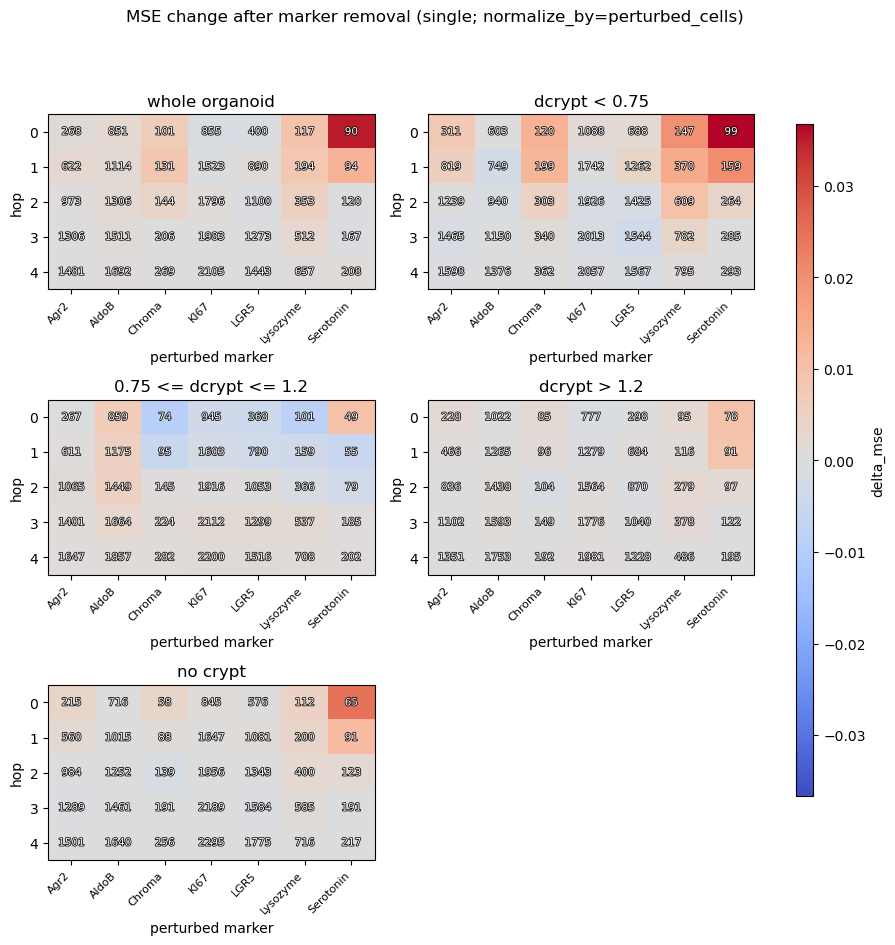

In [14]:
def plot_ablation_hop_marker_panels(df, value_col, mode, title, filename, *, group_order, n_cols=2, cmap="coolwarm", center_zero=True):
    sub = df[(df["mode"] == mode) & (df["group"].isin(group_order))].copy()
    groups = [g for g in group_order if g in set(sub["group"])]
    n_rows = max(1, int(np.ceil(len(groups) / n_cols)))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.4 * n_cols, 3.2 * n_rows), squeeze=False)
    finite_values = sub[value_col].to_numpy(dtype=float)
    if center_zero and np.any(np.isfinite(finite_values)):
        vmax = np.nanmax(np.abs(finite_values))
        vmin = -vmax
    else:
        vmin = vmax = None
    im = None
    for ax, group in zip(axes.ravel(), groups):
        group_df = sub[sub["group"] == group]
        table = (
            group_df
            .pivot(index="hop", columns="marker", values=value_col)
            .reindex(columns=marker_names)
            .sort_index()
        )
        annotation_table = (
            group_df
            .pivot(index="hop", columns="marker", values="cases")
            .reindex(index=table.index, columns=table.columns)
        )
        im = ax.imshow(table.to_numpy(dtype=float), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(DCRYPT_REGION_LABELS[group])
        ax.set_xlabel("perturbed marker")
        ax.set_ylabel("hop")
        ax.set_xticks(np.arange(len(marker_names)))
        ax.set_xticklabels(marker_names, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(np.arange(len(table.index)))
        ax.set_yticklabels(table.index)
        annotate_heatmap_cells(ax, annotation_table, fontsize=7.5)
    for ax in axes.ravel()[len(groups):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout(rect=[0.0, 0.0, 0.88, 0.94])
    if im is not None:
        cax = fig.add_axes([0.91, 0.16, 0.02, 0.70])
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(value_col)
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


for mode in ABLATION_MODES:
    normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, "perturbed_cells")
    mode_label = f"{mode}; normalize_by={normalize_by}"
    plot_ablation_hop_marker_panels(
        center_inclusive_ablation_df,
        "delta_mu",
        mode,
        f"Prediction change after marker removal ({mode_label})",
        f"center_inclusive_ablation_delta_mu_hop_marker_{mode}",
        group_order=DCRYPT_REGION_ORDER,
        n_cols=2,
    )
    plot_ablation_hop_marker_panels(
        center_inclusive_ablation_df,
        "delta_mse",
        mode,
        f"MSE change after marker removal ({mode_label})",
        f"center_inclusive_ablation_delta_mse_hop_marker_{mode}",
        group_order=DCRYPT_REGION_ORDER,
        n_cols=2,
    )

**Whole-Organoid Distance Curves**

For the whole organoid, plot each marker as a curve over distance so the apparent predictiveness radius is easier to read.

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/center_inclusive_marker_ablation_radius/run_20260605_160706/figures/whole_organoid_delta_mu_distance_marker_subplots_single.pdf


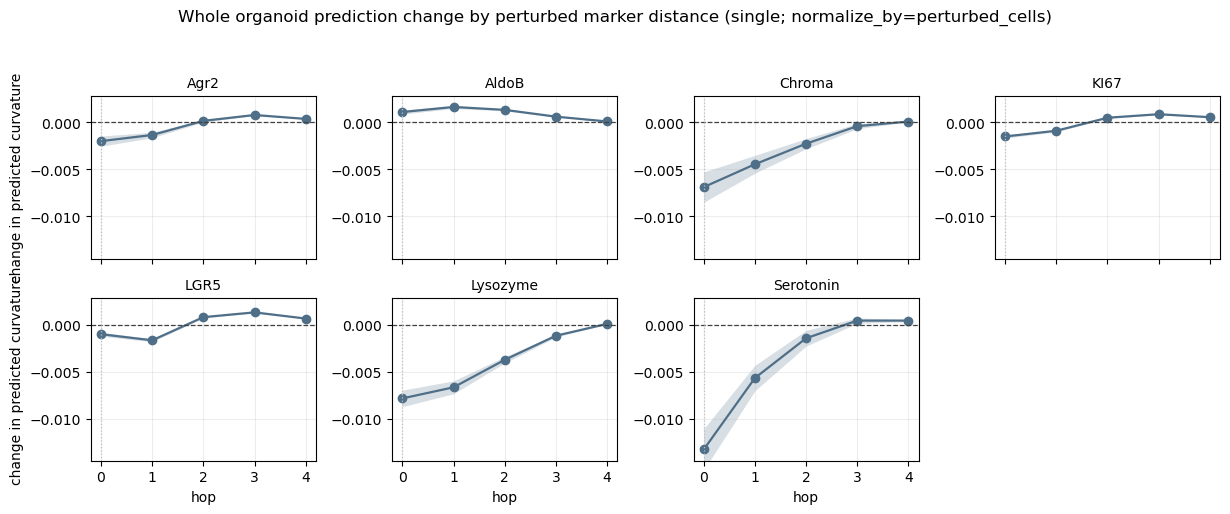

Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/center_inclusive_marker_ablation_radius/run_20260605_160706/figures/whole_organoid_delta_mse_distance_marker_subplots_single.pdf


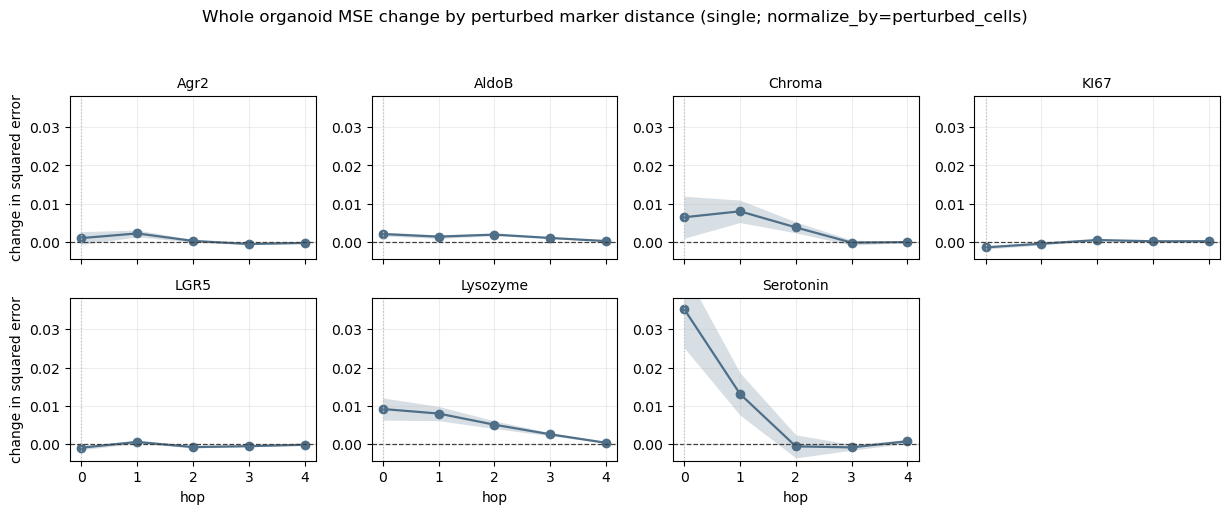

In [15]:
def summarize_case_effects_for_curves(case_df, value_col):
    rows = []
    grouped = case_df.groupby(["mode", "marker", "marker_index", "hop"], sort=True)
    for (mode, marker, marker_index, hop), sub in grouped:
        values = sub[value_col].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        n = int(values.size)
        if n == 0:
            mean = std = sem_val = np.nan
        else:
            mean = float(np.mean(values))
            std = float(np.std(values, ddof=1)) if n > 1 else 0.0
            sem_val = float(std / np.sqrt(n)) if n > 1 else 0.0
        rows.append({
            "mode": mode,
            "marker": marker,
            "marker_index": int(marker_index),
            "hop": int(hop),
            "mean": mean,
            "std": std,
            "sem": sem_val,
            "cases": n,
        })
    return pd.DataFrame(rows)


def plot_whole_organoid_marker_subplots(case_df, value_col, mode, title, filename, *, ylabel):
    sub = case_df[(case_df["group"] == "whole_organoid") & (case_df["mode"] == mode)].copy()
    summary = summarize_case_effects_for_curves(sub, value_col)

    n_markers = len(marker_names)
    n_cols = min(4, n_markers)
    n_rows = int(np.ceil(n_markers / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.1 * n_cols, 2.6 * n_rows),
        sharex=True,
        sharey=False,
        squeeze=False,
    )

    finite = summary["mean"].to_numpy(dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size:
        ypad = 0.08 * max(np.ptp(finite), np.max(np.abs(finite)), 1e-12)
        ymin = float(np.min(finite) - ypad)
        ymax = float(np.max(finite) + ypad)
    else:
        ymin, ymax = -1.0, 1.0

    for ax, marker in zip(axes.ravel(), marker_names):
        mdf = summary[summary["marker"] == marker].sort_values("hop")
        x = mdf["hop"].to_numpy(dtype=float)
        y = mdf["mean"].to_numpy(dtype=float)
        e = mdf["sem"].to_numpy(dtype=float)
        ax.plot(x, y, marker="o", linewidth=1.6, color="#4f6f88")
        ax.fill_between(x, y - e, y + e, color="#4f6f88", alpha=0.22, linewidth=0)
        ax.axhline(0, color="0.25", linestyle="--", linewidth=0.9)
        ax.axvline(0, color="0.75", linestyle=":", linewidth=0.9)
        ax.set_title(marker, fontsize=10)
        ax.set_xticks(np.arange(0, NUM_LAYERS + 1))
        ax.grid(True, alpha=0.22)
        ax.set_ylim(ymin, ymax)
    for ax in axes.ravel()[n_markers:]:
        ax.axis("off")

    for ax in axes[-1, :]:
        ax.set_xlabel("hop")
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel)

    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


for mode in ABLATION_MODES:
    normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, "perturbed_cells")
    mode_label = f"{mode}; normalize_by={normalize_by}"
    plot_whole_organoid_marker_subplots(
        center_inclusive_ablation_case_df,
        "delta_mu",
        mode,
        f"Whole organoid prediction change by perturbed marker distance ({mode_label})",
        f"whole_organoid_delta_mu_distance_marker_subplots_{mode}",
        ylabel="change in predicted curvature",
    )
    plot_whole_organoid_marker_subplots(
        center_inclusive_ablation_case_df,
        "delta_mse",
        mode,
        f"Whole organoid MSE change by perturbed marker distance ({mode_label})",
        f"whole_organoid_delta_mse_distance_marker_subplots_{mode}",
        ylabel="change in squared error",
    )


Saved figure -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/center_inclusive_marker_ablation_radius/run_20260605_160706/figures/region_curves_delta_mu_distance_marker_subplots_single.pdf


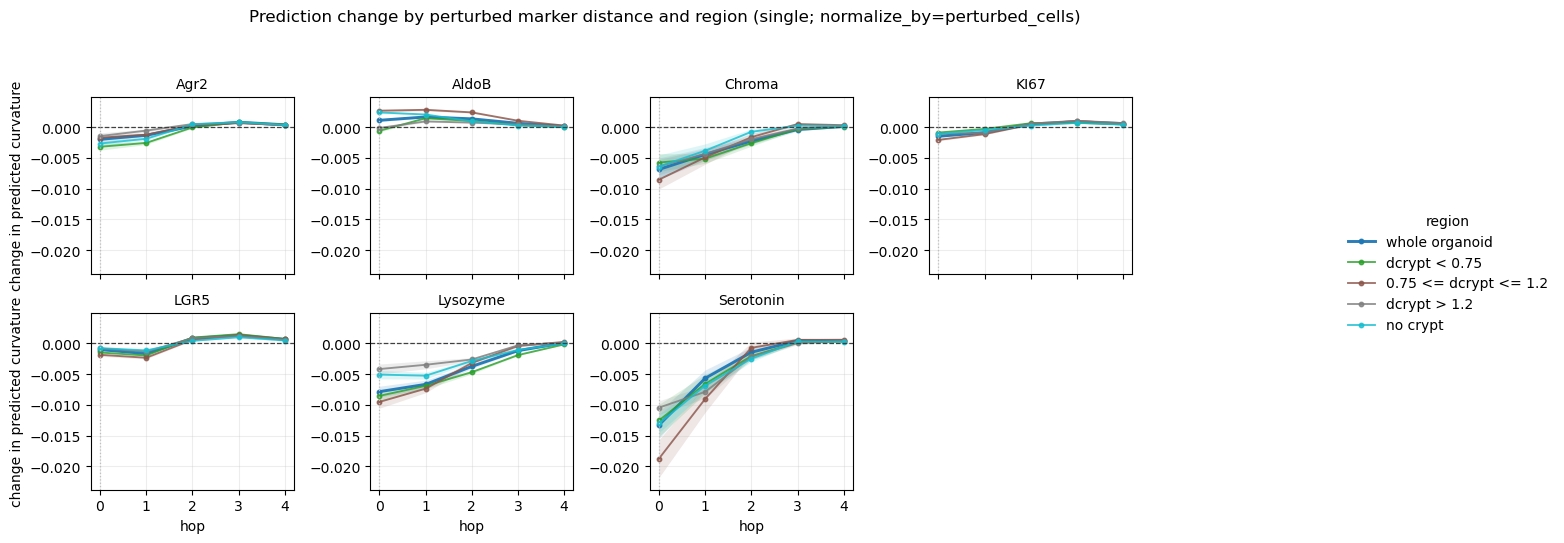

In [16]:
def summarize_case_effects_for_region_curves(case_df, value_col):
    rows = []
    grouped = case_df.groupby(["mode", "group", "label", "marker", "marker_index", "hop"], sort=True)
    for (mode, group, label, marker, marker_index, hop), sub in grouped:
        values = sub[value_col].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        n = int(values.size)
        if n == 0:
            mean = std = sem_val = np.nan
        else:
            mean = float(np.mean(values))
            std = float(np.std(values, ddof=1)) if n > 1 else 0.0
            sem_val = float(std / np.sqrt(n)) if n > 1 else 0.0
        rows.append({
            "mode": mode,
            "group": group,
            "label": label,
            "marker": marker,
            "marker_index": int(marker_index),
            "hop": int(hop),
            "mean": mean,
            "std": std,
            "sem": sem_val,
            "cases": n,
        })
    return pd.DataFrame(rows)


def plot_region_curves_by_marker(case_df, value_col, mode, title, filename, *, ylabel):
    summary = summarize_case_effects_for_region_curves(
        case_df[case_df["mode"] == mode].copy(),
        value_col,
    )
    groups = [group for group in DCRYPT_REGION_ORDER if group in set(summary["group"])]
    group_colors = dict(zip(groups, plt.cm.tab10(np.linspace(0, 1, max(len(groups), 1)))))

    n_markers = len(marker_names)
    n_cols = min(4, n_markers)
    n_rows = int(np.ceil(n_markers / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.35 * n_cols, 2.75 * n_rows),
        sharex=True,
        sharey=False,
        squeeze=False,
    )

    finite_low = (summary["mean"] - summary["sem"]).to_numpy(dtype=float)
    finite_high = (summary["mean"] + summary["sem"]).to_numpy(dtype=float)
    finite = np.concatenate([finite_low, finite_high])
    finite = finite[np.isfinite(finite)]
    if finite.size:
        ypad = 0.08 * max(np.ptp(finite), np.max(np.abs(finite)), 1e-12)
        ymin = float(np.min(finite) - ypad)
        ymax = float(np.max(finite) + ypad)
    else:
        ymin, ymax = -1.0, 1.0

    for ax, marker in zip(axes.ravel(), marker_names):
        marker_df = summary[summary["marker"] == marker]
        for group in groups:
            mdf = marker_df[marker_df["group"] == group].sort_values("hop")
            if mdf.empty:
                continue
            x = mdf["hop"].to_numpy(dtype=float)
            y = mdf["mean"].to_numpy(dtype=float)
            e = mdf["sem"].to_numpy(dtype=float)
            color = group_colors[group]
            linewidth = 2.1 if group == "whole_organoid" else 1.35
            alpha = 0.95 if group == "whole_organoid" else 0.82
            ax.plot(
                x,
                y,
                marker="o",
                markersize=3.2,
                linewidth=linewidth,
                color=color,
                alpha=alpha,
                label=DCRYPT_REGION_LABELS[group],
            )
            ax.fill_between(x, y - e, y + e, color=color, alpha=0.14, linewidth=0)
        ax.axhline(0, color="0.25", linestyle="--", linewidth=0.9)
        ax.axvline(0, color="0.75", linestyle=":", linewidth=0.9)
        ax.set_title(marker, fontsize=10)
        ax.set_xticks(np.arange(0, NUM_LAYERS + 1))
        ax.grid(True, alpha=0.22)
        ax.set_ylim(ymin, ymax)
    for ax in axes.ravel()[n_markers:]:
        ax.axis("off")

    for ax in axes[-1, :]:
        ax.set_xlabel("hop")
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel)

    handles, labels = axes.ravel()[0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(1.0, 0.5),
            frameon=False,
            title="region",
        )
    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0, 0.86, 0.94])
    save_mpl_figure(fig, filename)
    plt.show()
    return fig, axes


for mode in ABLATION_MODES:
    normalize_by = ABLATION_NORMALIZE_BY_BY_MODE.get(mode, "perturbed_cells")
    mode_label = f"{mode}; normalize_by={normalize_by}"
    plot_region_curves_by_marker(
        center_inclusive_ablation_case_df,
        "delta_mu",
        mode,
        f"Prediction change by perturbed marker distance and region ({mode_label})",
        f"region_curves_delta_mu_distance_marker_subplots_{mode}",
        ylabel="change in predicted curvature",
    )


**Center Stratification Versus Hop-0 Ablation**

Compare two ways of estimating the center-marker effect. Stratification uses the unperturbed difference between marker-positive and marker-negative center cells. Hop-0 ablation uses the signed effect of marker presence, computed as the negative of the marker-removal delta.


,label,marker,marker_index,n_positive,n_negative,delta_pred_pos_minus_neg,var_delta_pred_pos_minus_neg,sem_delta_pred_pos_minus_neg,n_ablation_cases,k0_removal_delta_mu_mean,k0_removal_delta_mu_var,k0_removal_delta_mu_sem,k0_presence_effect_mean,k0_presence_effect_var,k0_presence_effect_sem,mean_difference_k0_minus_stratification,variance_difference_k0_minus_stratification
0,whole organoid,Agr2,0,6078,109741,0.012915,0.001942,0.000421,268,-0.001989,0.000079,0.000543,0.001989,0.000079,0.000543,-0.010926,-0.001863
1,whole organoid,AldoB,1,43706,72113,-0.008354,0.001795,0.000180,851,0.001104,0.000040,0.000217,-0.001104,0.000040,0.000217,0.007250,-0.001755
2,whole organoid,Chroma,2,536,115283,0.042403,0.002244,0.001574,101,-0.006878,0.000262,0.001611,0.006878,0.000262,0.001611,-0.035524,-0.001981
3,whole organoid,KI67,3,38021,77798,0.006588,0.001771,0.000183,855,-0.001495,0.000024,0.000169,0.001495,0.000024,0.000169,-0.005093,-0.001747
4,whole organoid,LGR5,4,18087,97732,0.022845,0.001419,0.000191,400,-0.001029,0.000018,0.000215,0.001029,0.000018,0.000215,-0.021816,-0.001400
5,whole organoid,Lysozyme,5,1480,114339,0.035400,0.001538,0.000654,117,-0.007855,0.000091,0.000882,0.007855,0.000091,0.000882,-0.027546,-0.001447
6,whole organoid,Serotonin,6,436,115383,0.053978,0.002077,0.001633,90,-0.013287,0.000434,0.002197,0.013287,0.000434,0.002197,-0.040692,-0.001642
7,dcrypt < 0.75,Agr2,0,1784,20130,0.013419,0.001666,0.000731,311,-0.003199,0.000097,0.000558,0.003199,0.000097,0.000558,-0.010220,-0.001569
8,dcrypt < 0.75,AldoB,1,5396,16518,-0.011841,0.001205,0.000324,603,-0.000598,0.000025,0.000202,0.000598,0.000025,0.000202,0.012440,-0.001181
9,dcrypt < 0.75,Chroma,2,288,21626,0.038051,0.002036,0.002097,120,-0.005754,0.000250,0.001442,0.005754,0.000250,0.001442,-0.032297,-0.001786


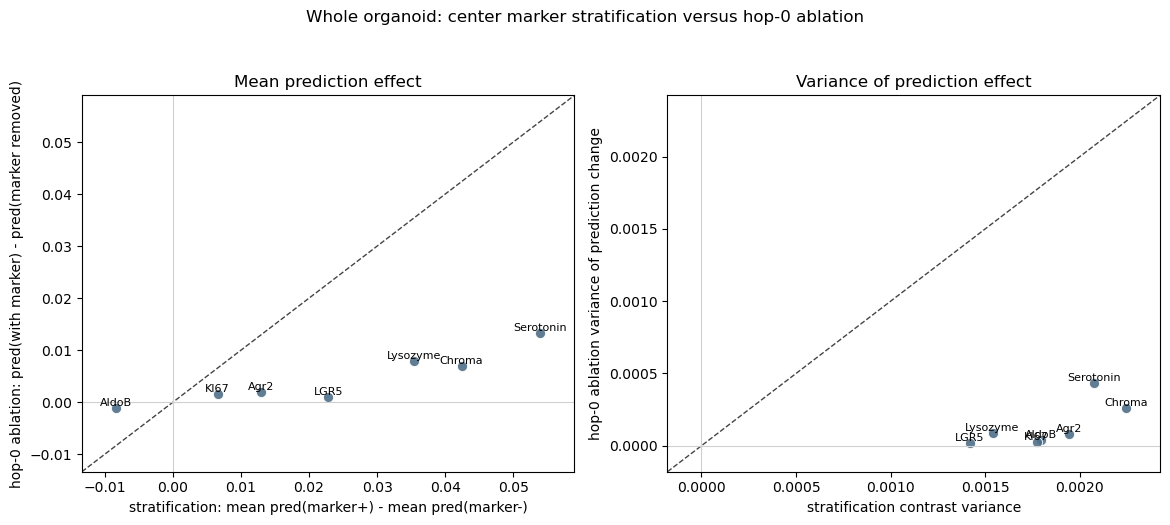

In [17]:
def summarize_k0_ablation_vs_stratification(strat_df, case_df, *, mode="single"):
    k0 = case_df[(case_df["hop"] == 0) & (case_df["mode"] == mode)].copy()
    ablation_rows = []
    for (group, label, marker, marker_index), sub in k0.groupby(["group", "label", "marker", "marker_index"], sort=False):
        values = sub["delta_mu"].to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        n = int(values.size)
        if n == 0:
            mean_removal = var_removal = sem_removal = np.nan
        else:
            mean_removal = float(np.mean(values))
            std_removal = float(np.std(values, ddof=1)) if n > 1 else 0.0
            var_removal = float(std_removal ** 2)
            sem_removal = float(std_removal / np.sqrt(n)) if n > 1 else 0.0
        ablation_rows.append({
            "group": group,
            "label": label,
            "marker": marker,
            "marker_index": int(marker_index),
            "n_ablation_cases": n,
            "k0_removal_delta_mu_mean": mean_removal,
            "k0_removal_delta_mu_var": var_removal,
            "k0_removal_delta_mu_sem": sem_removal,
            "k0_presence_effect_mean": -mean_removal if np.isfinite(mean_removal) else np.nan,
            "k0_presence_effect_var": var_removal,
            "k0_presence_effect_sem": sem_removal,
        })
    ablation_summary = pd.DataFrame(ablation_rows)

    keep_cols = [
        "group",
        "label",
        "marker",
        "marker_index",
        "n_positive",
        "n_negative",
        "delta_pred_pos_minus_neg",
        "var_delta_pred_pos_minus_neg",
        "sem_delta_pred_pos_minus_neg",
    ]
    out = strat_df[keep_cols].merge(
        ablation_summary,
        on=["group", "label", "marker", "marker_index"],
        how="left",
    )
    out["mean_difference_k0_minus_stratification"] = out["k0_presence_effect_mean"] - out["delta_pred_pos_minus_neg"]
    out["variance_difference_k0_minus_stratification"] = out["k0_presence_effect_var"] - out["var_delta_pred_pos_minus_neg"]
    return out


k0_ablation_stratification_comparison_df = summarize_k0_ablation_vs_stratification(
    center_marker_stratification_contrast_df,
    center_inclusive_ablation_case_df,
    mode="single",
)
display_table(k0_ablation_stratification_comparison_df, head=12)


def _equal_limits(x, y, *, pad_frac=0.08, include_zero=True):
    vals = np.concatenate([np.asarray(x, dtype=float), np.asarray(y, dtype=float)])
    vals = vals[np.isfinite(vals)]
    if include_zero:
        vals = np.concatenate([vals, np.asarray([0.0])])
    if vals.size == 0:
        return (-1.0, 1.0)
    lo = float(np.min(vals))
    hi = float(np.max(vals))
    if np.isclose(lo, hi):
        span = max(abs(lo), 1.0)
        lo -= 0.1 * span
        hi += 0.1 * span
    pad = pad_frac * (hi - lo)
    return lo - pad, hi + pad


def plot_k0_ablation_stratification_comparison(df):
    df = df[df["group"] == "whole_organoid"].copy()
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.0))
    point_color = "#4f6f88"

    panels = [
        {
            "ax": axes[0],
            "x": "delta_pred_pos_minus_neg",
            "y": "k0_presence_effect_mean",
            "xlabel": "stratification: mean pred(marker+) - mean pred(marker-)",
            "ylabel": "hop-0 ablation: pred(with marker) - pred(marker removed)",
            "title": "Mean prediction effect",
            "include_zero": True,
        },
        {
            "ax": axes[1],
            "x": "var_delta_pred_pos_minus_neg",
            "y": "k0_presence_effect_var",
            "xlabel": "stratification contrast variance",
            "ylabel": "hop-0 ablation variance of prediction change",
            "title": "Variance of prediction effect",
            "include_zero": True,
        },
    ]

    for panel in panels:
        ax = panel["ax"]
        ax.scatter(
            df[panel["x"]],
            df[panel["y"]],
            s=54,
            color=point_color,
            edgecolor="white",
            linewidth=0.7,
            alpha=0.9,
        )
        for _, row in df.iterrows():
            if np.isfinite(row[panel["x"]]) and np.isfinite(row[panel["y"]]):
                ax.text(
                    row[panel["x"]],
                    row[panel["y"]],
                    str(row["marker"]),
                    fontsize=8,
                    ha="center",
                    va="bottom",
                )
        lo, hi = _equal_limits(df[panel["x"]], df[panel["y"]], include_zero=panel["include_zero"])
        ax.plot([lo, hi], [lo, hi], linestyle="--", color="#444444", linewidth=1.0)
        ax.axhline(0, color="#d0d0d0", linewidth=0.8)
        ax.axvline(0, color="#d0d0d0", linewidth=0.8)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel(panel["xlabel"])
        ax.set_ylabel(panel["ylabel"])
        ax.set_title(panel["title"])

    fig.suptitle("Whole organoid: center marker stratification versus hop-0 ablation", y=1.04)
    fig.tight_layout()
    return fig, axes


fig, axes = plot_k0_ablation_stratification_comparison(k0_ablation_stratification_comparison_df)


**Save Results**

In [18]:
def _jsonable(obj):
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, torch.dtype):
        return str(obj)
    if isinstance(obj, np.dtype):
        return str(obj)
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


SAVE_DIR.mkdir(parents=True, exist_ok=True)
center_marker_stratification_df.to_csv(SAVE_DIR / "center_marker_stratification_metrics.csv", index=False)
center_marker_stratification_contrast_df.to_csv(SAVE_DIR / "center_marker_stratification_contrasts.csv", index=False)
group_subgraph_info.to_csv(SAVE_DIR / "group_subgraph_counts.csv", index=False)
center_inclusive_ablation_df.to_csv(SAVE_DIR / "center_inclusive_ablation_metrics.csv", index=False)
center_inclusive_ablation_case_df.to_csv(SAVE_DIR / "center_inclusive_ablation_case_metrics.csv", index=False)
k0_ablation_stratification_comparison_df.to_csv(SAVE_DIR / "k0_ablation_vs_center_marker_stratification.csv", index=False)
analysis_group_count_df.to_csv(SAVE_DIR / "analysis_group_node_counts.csv", index=False)

experiment_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "dataset_name": DATASET_NAME,
    "target_indices": TARGET_INDICES,
    "target_index_for_plots": TARGET_INDEX_FOR_PLOTS,
    "use_global_features": USE_GLOBAL_FEATURES,
    "filter_blacklisted_organoids": FILTER_BLACKLISTED_ORGANOIDS,
    "subtract_constant_global_baseline": SUBTRACT_CONSTANT_GLOBAL_BASELINE,
    "target_transform": target_transform.name,
    "dcrypt_field": DCRYPT_FIELD,
    "dcrypt_region_order": DCRYPT_REGION_ORDER,
    "model": {
        "class": MODEL_CLASS,
        "num_layers": NUM_LAYERS,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "norm": NORM,
        "residual": RESIDUAL,
    },
    "training": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_weight": EDGE_LOSS_WEIGHT,
        "edge_loss_params": EDGE_LOSS_PARAMS,
    },
    "ablation": {
        "modes": ABLATION_MODES,
        "normalize_by_by_mode": ABLATION_NORMALIZE_BY_BY_MODE,
        "max_subgraphs_per_group": MAX_SUBGRAPHS_PER_GROUP,
        "min_center_marker_occurrences": MIN_CENTER_MARKER_OCCURRENCES,
        "min_group_nodes": MIN_GROUP_NODES,
        "batch_size": PERTURBATION_BATCH_SIZE,
        "hops": list(range(0, NUM_LAYERS + 1)),
    },
    "filters": {
        "blacklist_n_keys": len(blacklist),
        "missing_complexity_group": MISSING_COMPLEXITY_GROUP,
        "sphericity_max": SPHERICITY_MAX,
        "spherical_marker_diversity_min": SPHERICAL_MARKER_DIVERSITY_MIN,
        "complexity_min": COMPLEXITY_MIN,
        "interpolate_target_outliers": INTERPOLATE_TARGET_OUTLIERS,
        "outlier_clip_quantiles": OUTLIER_CLIP_QUANTILES,
    },
    "split": {
        "val_frac": VAL_FRAC,
        "split_seed": SPLIT_SEED,
    },
    "n_train_graphs": len(g_train),
    "n_val_graphs": len(g_val),
    "marker_names": list(marker_names),
    "field_specs": field_specs,
    "figures_dir": str(FIGURES_DIR),
}
with open(SAVE_DIR / "config.json", "w") as f:
    json.dump(_jsonable(experiment_config), f, indent=2)
with open(SAVE_DIR / "training_log.pkl", "wb") as f:
    pickle.dump(training_log, f)
print(f"Saved experiment -> {SAVE_DIR}")

Saved experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/center_inclusive_marker_ablation_radius/run_20260605_160706
